# Heart disease analysis

## Feature info

    Age: age of the patient [years]
    Sex: sex of the patient [M: Male, F: Female]
    ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
    RestingBP: resting blood pressure [mm Hg]
    Cholesterol: serum cholesterol [mm/dl]
    FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
    RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
    MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
    ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
    Oldpeak: oldpeak = ST [Numeric value measured in depression]
    ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
    HeartDisease: output class [1: heart disease, 0: Normal

At first, we'll do some data exploration: we'll check dataset shape, feature types, missing values and outliers.

Since health adults can't have cholesterol and resting bp be zero, we'll look such samples and assign median values to them instead; 


In [192]:
from pyparsing import original_text_for
from pandas.core.series import Series
from statsmodels.stats.multitest import multipletests
from fontTools.misc.plistlib import Data
from pandas.core.frame import DataFrame
from scipy import stats
from IPython.display import display
import scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels


data:DataFrame = pd.read_csv("heart.csv")
print(f"shape: {data.shape[0]} rows, {data.shape[1]} columns.")
print(f"Has empty values: {data.isnull().values.any() or (data.isna().any().any())}")
print(f"Features and their types:\n{data.dtypes}")

shape: 918 rows, 12 columns.
Has empty values: False
Features and their types:
Age                 int64
Sex                   str
ChestPainType         str
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG            str
MaxHR               int64
ExerciseAngina        str
Oldpeak           float64
ST_Slope              str
HeartDisease        int64
dtype: object


Based on information about the dataset and what we see above, "HeartDisease", "Sex", "ChestPainType",  "RestingECG", "FastingBS",  "ExerciseAngina" and "ST_Slope" are nominal, the rest are ordinal data columns, and only the 'Oldpeak" is contitious. 

There are no empty values in our dataset. 

We will now check if there are any 0 values in numerical columns, where there shouldn't be any (cholesterol &　resting blood pressure) 


In [193]:
data_clean = data.copy()

print("Number of 0s in cholesterol & resting BP columns:")
for col in ['Cholesterol', 'RestingBP']:
    zeros = (data_clean[col] == 0).sum()
    print(f"  {col}: {zeros} zero(s)")

data_clean.loc[data_clean['Cholesterol'] == 0, 'Cholesterol'] = np.nan
data_clean.loc[data_clean['RestingBP'] == 0, 'RestingBP'] = np.nan

median_chol = data_clean['Cholesterol'].median()
median_bp = data_clean['RestingBP'].median()
print(f"\nMedian Cholesterol: {median_chol}, Median RestingBP: {median_bp}")

data_clean['Cholesterol'] = data_clean['Cholesterol'].fillna(median_chol)
data_clean['RestingBP'] = data_clean['RestingBP'].fillna(median_bp)


print("\nAfter filling missing values:")
print(data_clean[['Cholesterol', 'RestingBP']].isnull().sum())

Number of 0s in cholesterol & resting BP columns:
  Cholesterol: 172 zero(s)
  RestingBP: 1 zero(s)

Median Cholesterol: 237.0, Median RestingBP: 130.0

After filling missing values:
Cholesterol    0
RestingBP      0
dtype: int64


Now we'll find outliers via IQR among the numerical features


Outlier detection:
  Age: 0 outliers (0.00%)
  RestingBP: 27 outliers (2.94%)
  Cholesterol: 41 outliers (4.47%)
  MaxHR: 2 outliers (0.22%)
  Oldpeak: 16 outliers (1.74%)


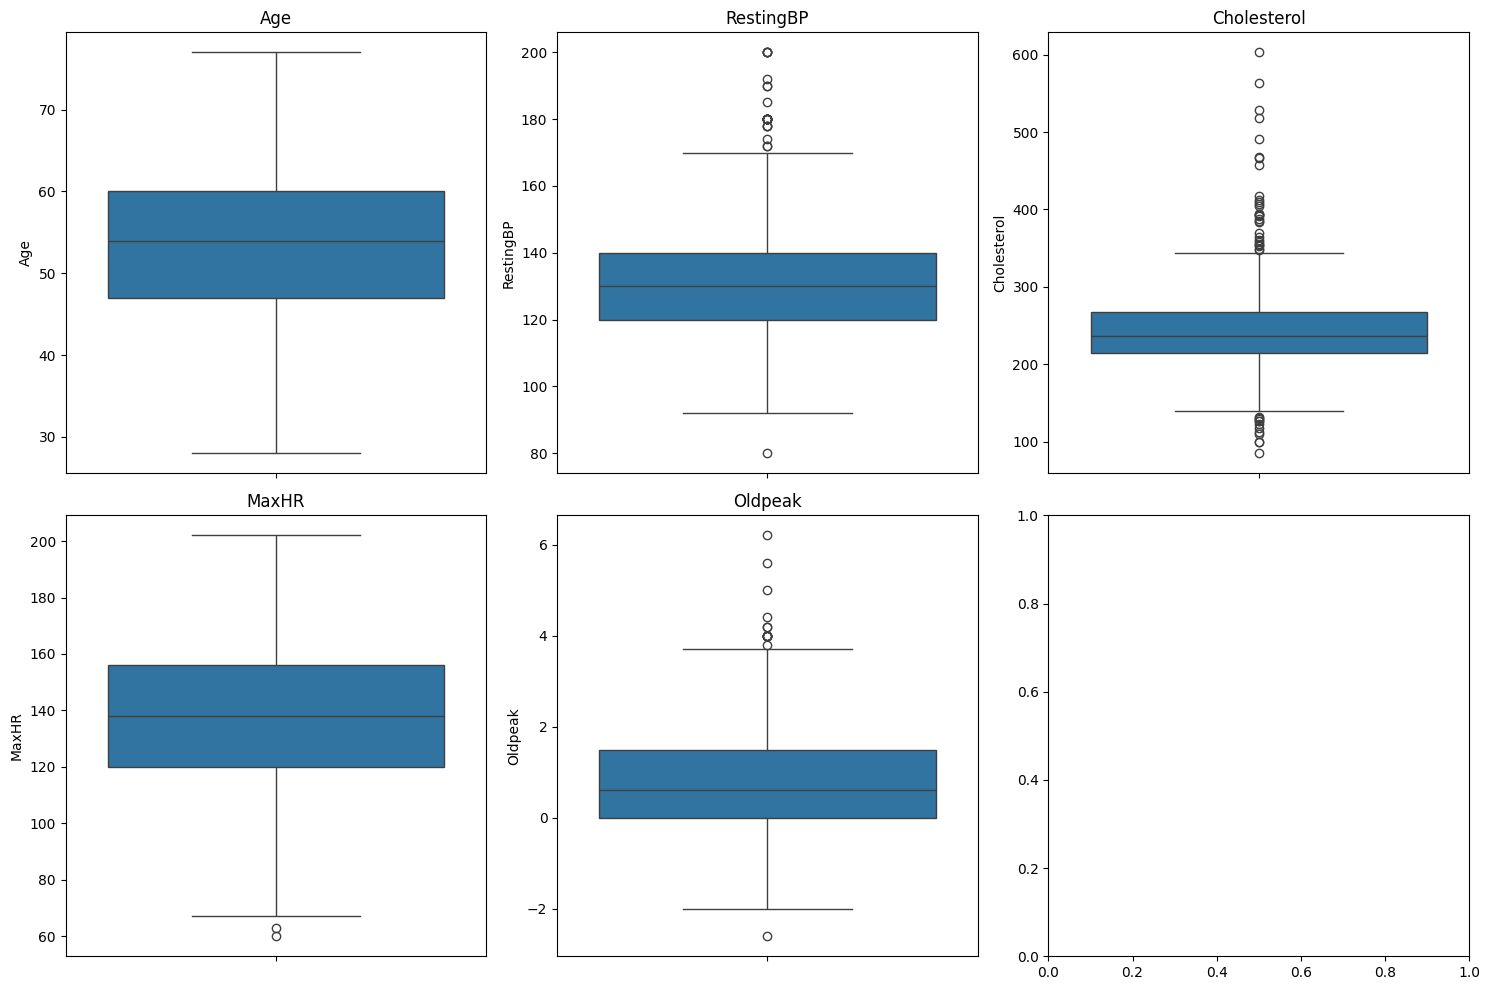

In [195]:
continuous = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
print("\nOutlier detection:")
for col in continuous:
    Q1 = data_clean[col].quantile(0.25)
    Q3 = data_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = data_clean[(data_clean[col] < lower) | (data_clean[col] > upper)]
    print(f"  {col}: {len(outliers)} outliers ({(len(outliers)/len(data_clean))*100:.2f}%)")


fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(continuous):
    sns.boxplot(y=col, data=data_clean, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

Some outliers exist in Cholesterol (~5%) and RestingBP (~3%). They may represent extreme but valid medical cases, so we won't get rid of them.

Let's take a look at how many people in our dataset have heart desease and how each of those features correlates with the illness:


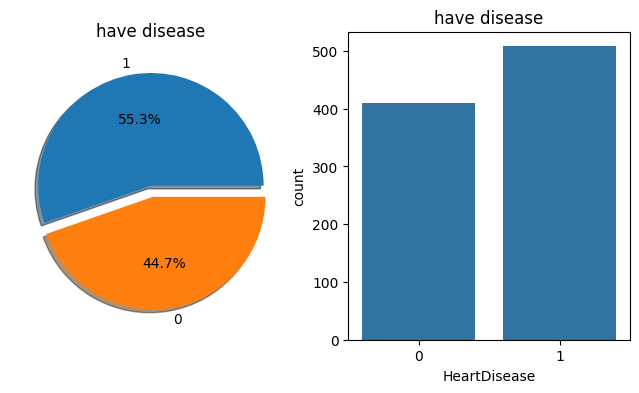

In [196]:
f, ax = plt.subplots(1, 2, figsize=(8, 4))

data_clean['HeartDisease'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True)
ax[0].set_title('have disease')
ax[0].set_ylabel('')

sns.countplot(data, x='HeartDisease', ax=ax[1])
ax[1].set_title('have disease')

plt.show()



The dataset is quite balanced with ~55% disease presence and ~45% no disease.

## Numerical features:
We'll look at numerical features on their own and in comparasment to the disease (uni and bivariate analysis)

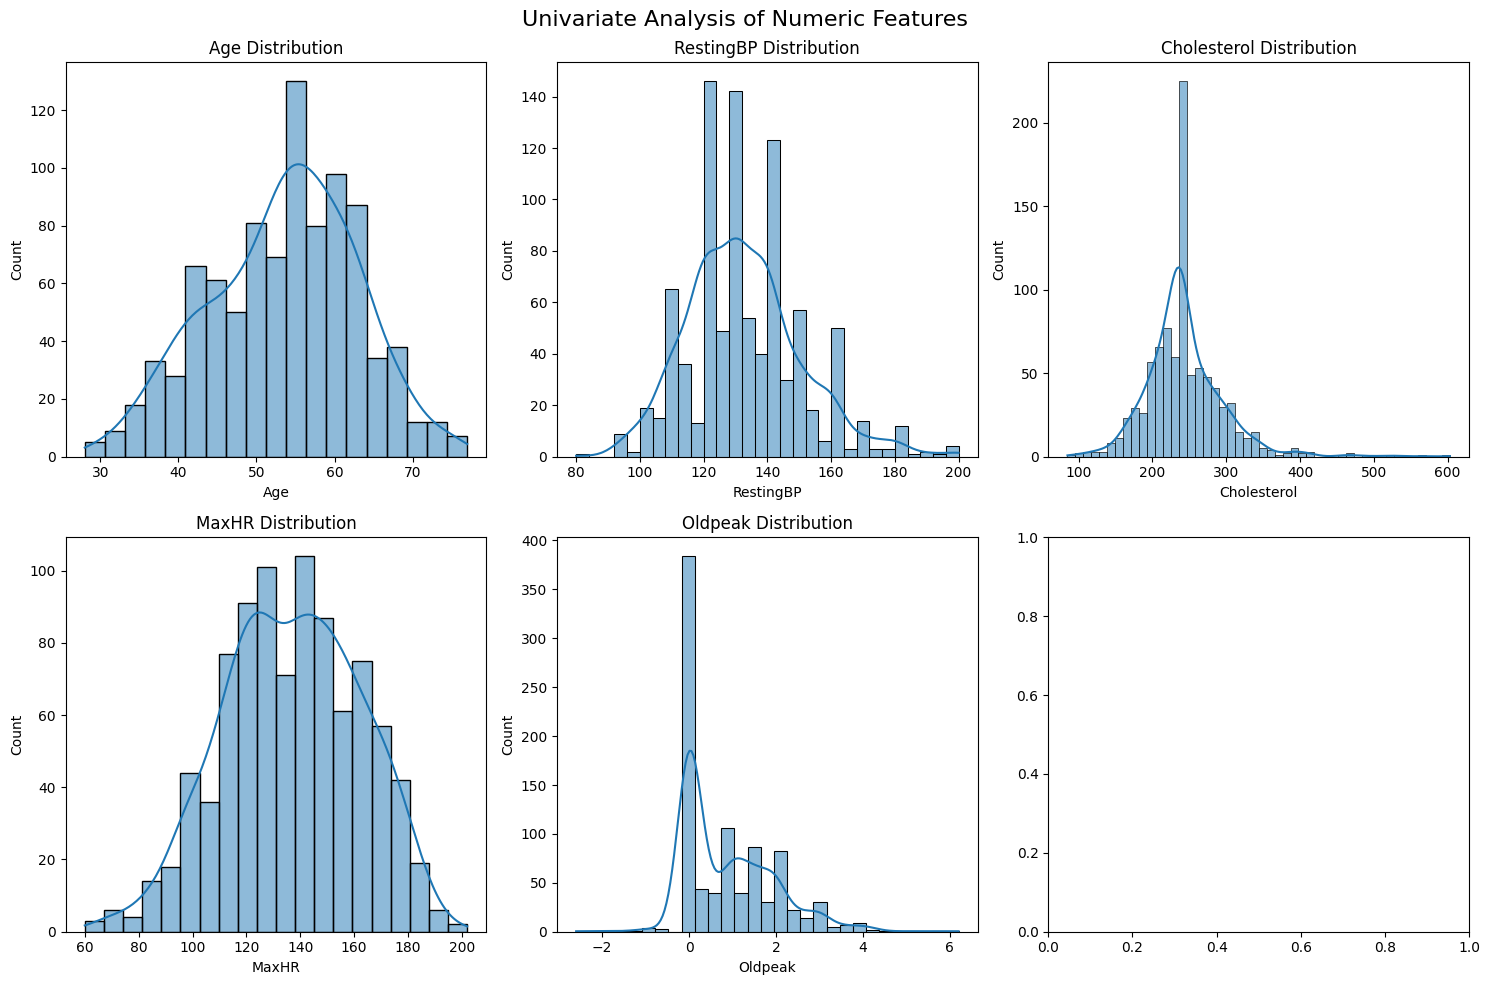

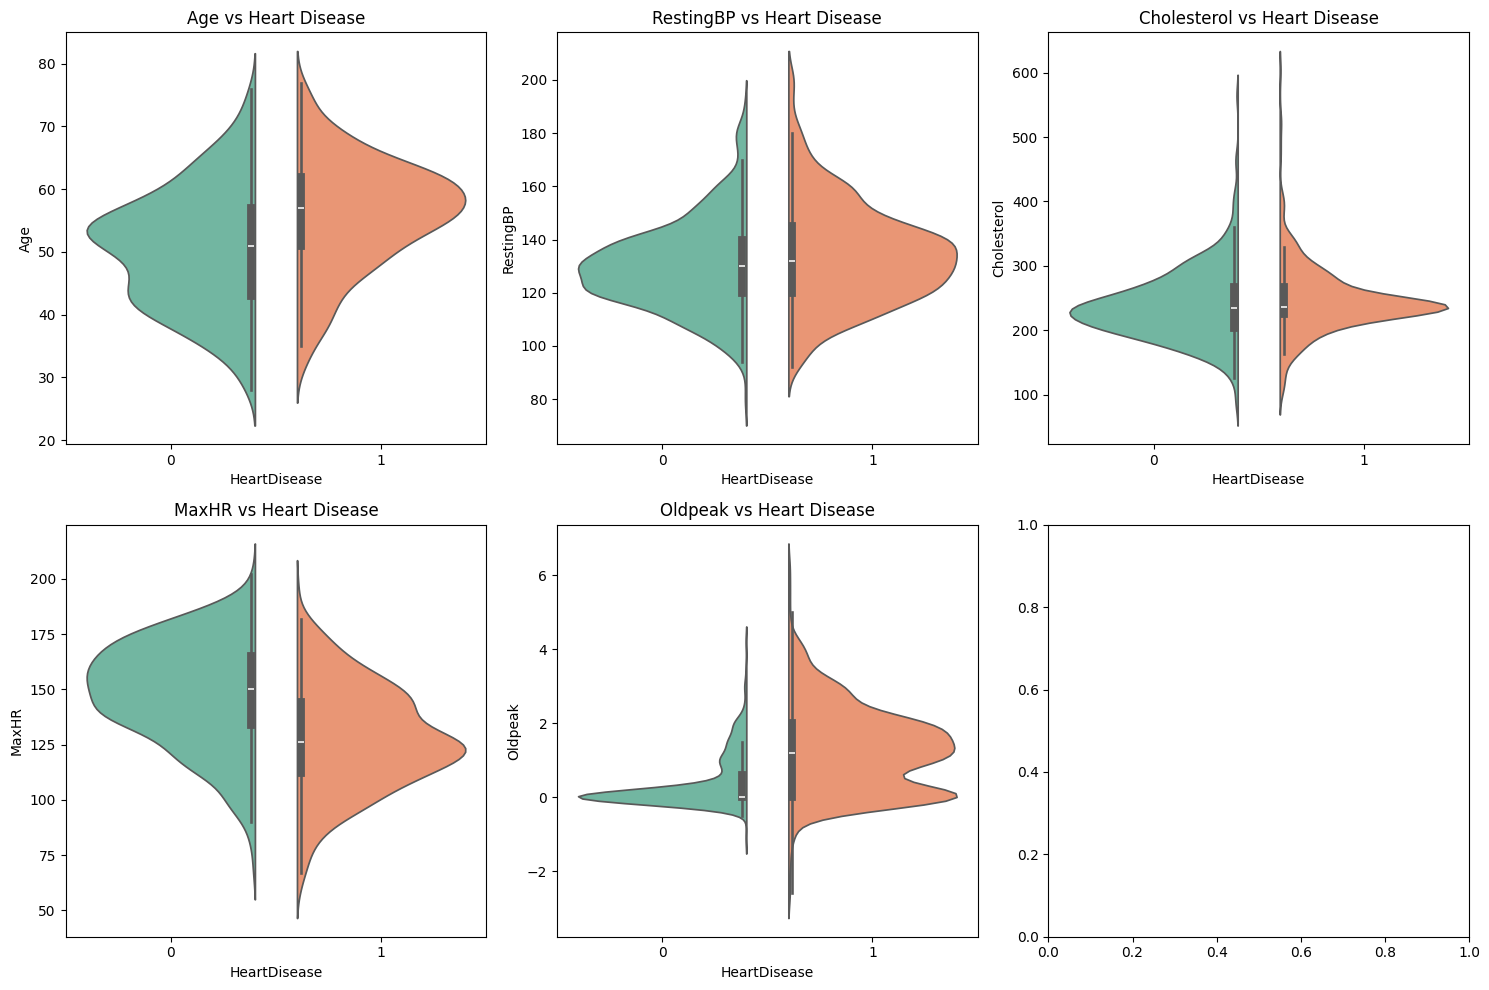

In [197]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Univariate Analysis of Numeric Features', fontsize=16)

cols = [c for c in data_clean.columns if (c in continuous)]
count = 0
for c in cols:
    sns.histplot(data_clean[c], kde=True, ax=axes[count//3,count%3])
    axes[count//3, count%3].set_title(f'{c} Distribution')
    count += 1


plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(continuous):
    sns.violinplot(x='HeartDisease', y=col, data=data_clean, ax=axes[i], palette='Set2', split=True)
    axes[i].set_title(f'{col} vs Heart Disease')
plt.tight_layout()
plt.show()



Those plots can highlight the following:
* The amount of heart diseases (HD) gradually increases with age.
* There is a slight correlation between a higher resting BP and heart disease.
* Chortisol seems to be weakly correlated with the HD.
* There seems to be a negative correlation between maximal heart rate and HD rates.
* Majority of subjects have the Oldpeak feature around 0. Those, who have a higher Oldpeak, are far more prone to having the disease.

## Nominal features

HeartDisease,0,1,All
Sex,,,
F,143,50,193
M,267,458,725
All,410,508,918


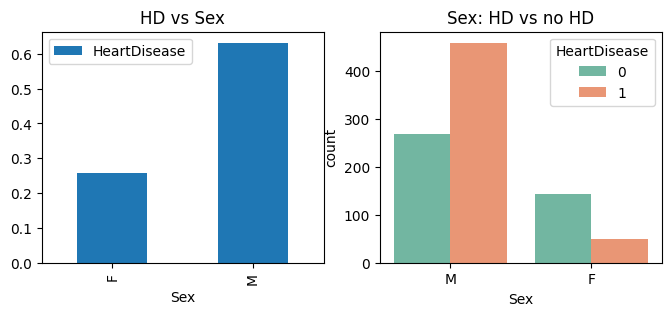

-------------------------------------------------------------------------------------


HeartDisease,0,1,All
ChestPainType,,,
ASY,104,392,496
ATA,149,24,173
NAP,131,72,203
TA,26,20,46
All,410,508,918


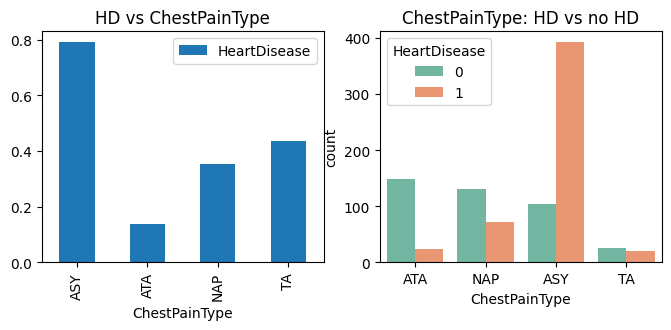

-------------------------------------------------------------------------------------


HeartDisease,0,1,All
RestingECG,,,
LVH,82,106,188
Normal,267,285,552
ST,61,117,178
All,410,508,918


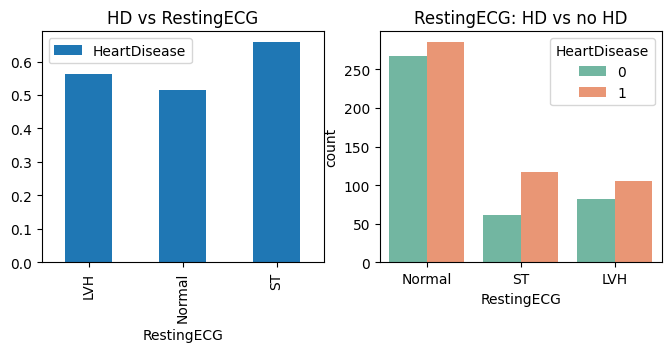

-------------------------------------------------------------------------------------


HeartDisease,0,1,All
ExerciseAngina,,,
N,355,192,547
Y,55,316,371
All,410,508,918


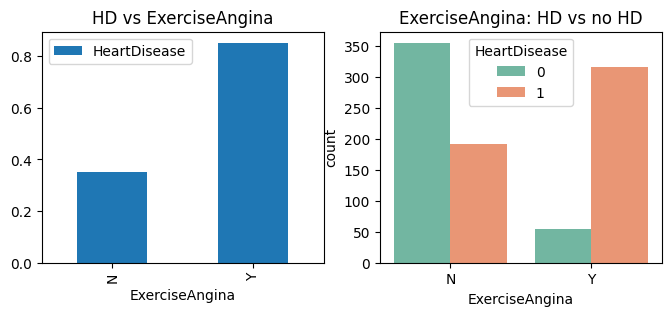

-------------------------------------------------------------------------------------


HeartDisease,0,1,All
ST_Slope,,,
Down,14,49,63
Flat,79,381,460
Up,317,78,395
All,410,508,918


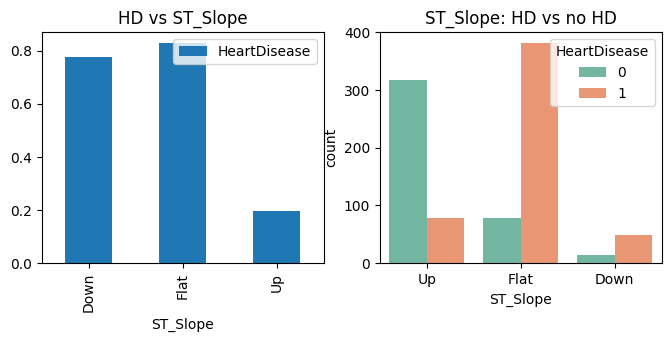

-------------------------------------------------------------------------------------


HeartDisease,0,1,All
FastingBS,,,
0,366,338,704
1,44,170,214
All,410,508,918


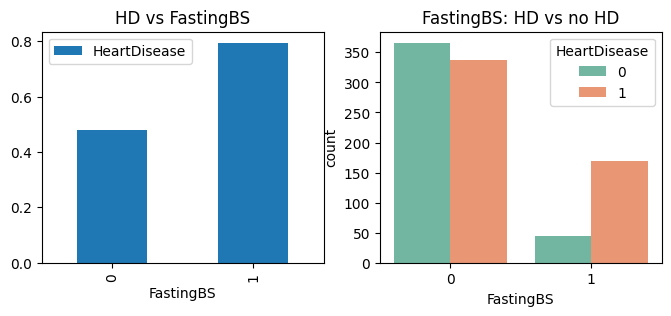

-------------------------------------------------------------------------------------


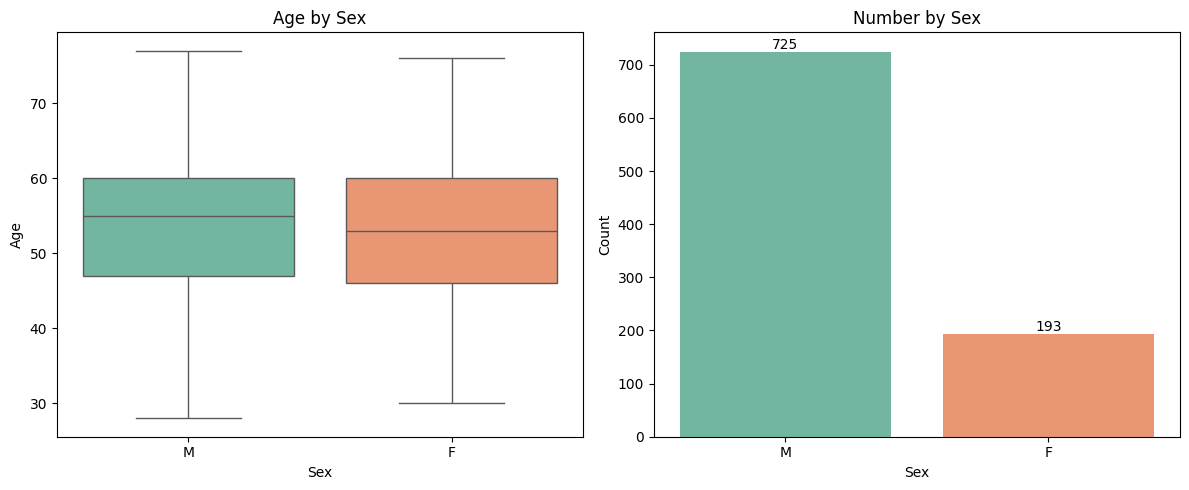

In [198]:
ordinals = ["Sex", "ChestPainType",  "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS"]
for el in ordinals:
    display(pd.crosstab(data[el], data["HeartDisease"], margins=True).style.background_gradient(cmap='summer_r'))
    
    f, ax=plt.subplots(1, 2, figsize=(8,3))

    data[[el,'HeartDisease']].groupby([el]).mean().plot.bar(ax=ax[0])
    ax[0].set_title(f'HD vs {el}')

    sns.countplot(data, x=el, hue='HeartDisease', ax=ax[1], palette='Set2')
    ax[1].set_title(f'{el}: HD vs no HD')

    plt.show()
    print("-------------------------------------------------------------------------------------")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Sex', y='Age', data=data_clean, ax=axes[0], palette='Set2')
axes[0].set_title('Age by Sex')
axes[0].set_xlabel('Sex')
axes[0].set_ylabel('Age')

sns.countplot(x='Sex', data=data_clean, ax=axes[1], palette='Set2')
axes[1].set_title('Number by Sex')
axes[1].set_xlabel('Sex')
axes[1].set_ylabel('Count')

for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', 
                     (p.get_x() + p.get_width()/2., p.get_height()),
                     ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()



Let's make some inintial assumptions, based on the plots & numbers above:

* men in this dataset are more likely to have heart disease -- 63% of people, having HD, are males.

* Heart diseases seem to be mostly asymptomatic (79%). Typical angina seems to be the least correlated with HD, even though people with HD seem to have it in abundance.

* Having resting ECG be in normal range can be somewhat corelated with not having a HD.

* Exercise-induced angina is a very strong indicator of heart disease (85% hd rate). although the amount of people not having it is smaller (35%), they are far more likely to have a healthy heart, in compalasment to those having it. 

* Having a flat ST slope has a heavy (~80%) corelation to the disease. Having the ST slope be 'up' (80% of those who have it 'up' are healthy) might be linked to healthier heart; little people have it, but those who do are mostly healthy. 

* Fasting blood sugar above 120 can be linked to heart problems (79% vs 48%).

The most prominent nominal features seem to be: sex, chest pain type, exercise angina and ST slope.

(We've also checked the age distribution between sexes amount of individuals of each sex. There is a good representation of different age groups in both men and women, which is good)

## Correlation analysis
We'll take a closer look at how strongly the numeral features correlate with having the disease.

['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


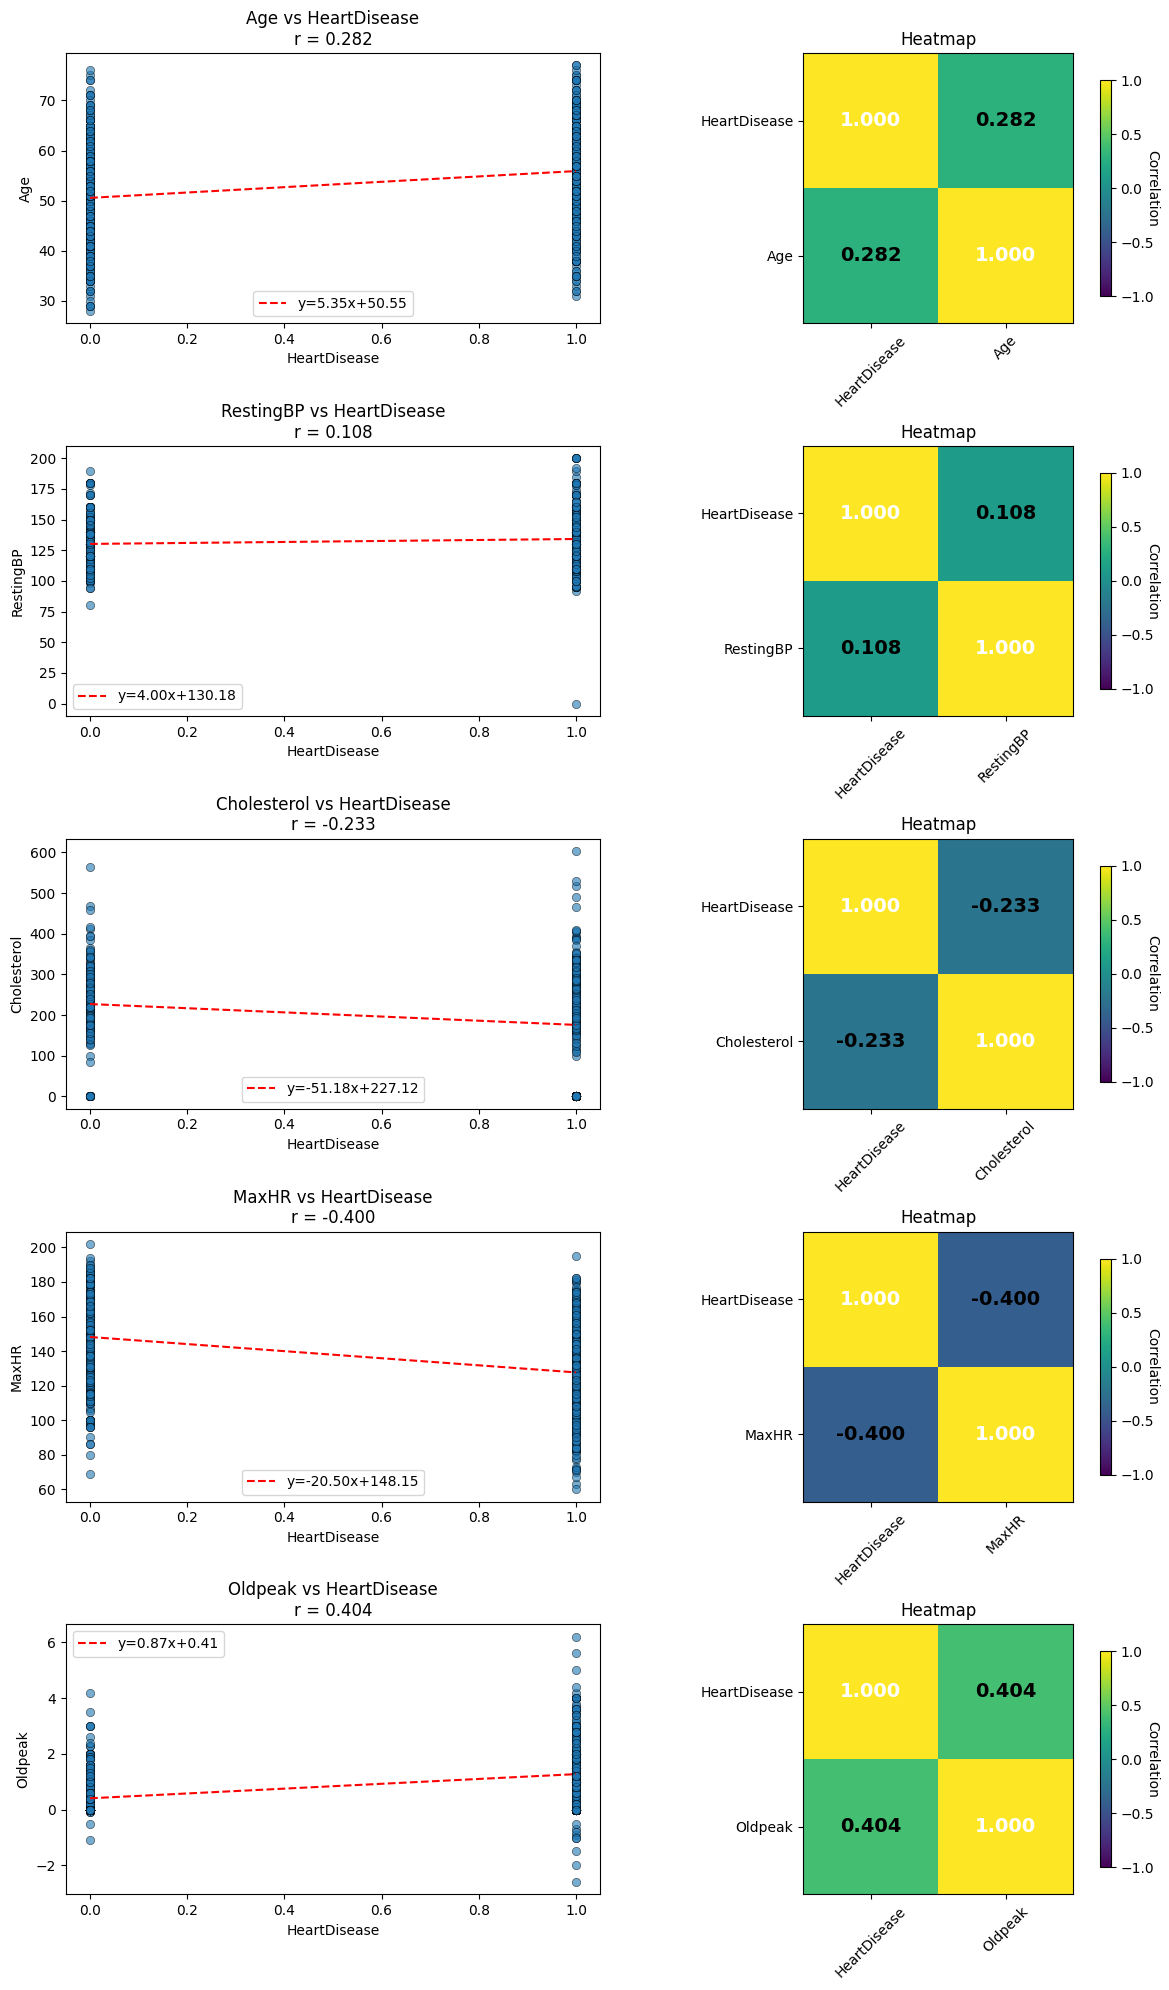

In [199]:
m = len(cols)
fig, axes = plt.subplots(m, 2, figsize=(12, 4 * m))
print(cols)
correls = []
for i, col in enumerate(cols):
    r = np.corrcoef(data['HeartDisease'], data[col])[0, 1]
    correls.append(r)
    ax1 = axes[i, 0] if m > 1 else axes[0]
    ax1.scatter(data['HeartDisease'], data[col], alpha=0.6, edgecolor='k', linewidth=0.5)
    ax1.set(xlabel='HeartDisease', ylabel=col, title=f'{col} vs HeartDisease\nr = {r:.3f}')
    mm, b = np.polyfit(data['HeartDisease'], data[col], 1)
    x = np.linspace(data['HeartDisease'].min(), data['HeartDisease'].max(), 100)
    ax1.plot(x, mm*x + b, 'r--', label=f'y={mm:.2f}x+{b:.2f}')
    ax1.legend()
    
    ax2 = axes[i, 1] if m > 1 else axes[1]
    corr_mat = [[1, r], [r, 1]]
    im = ax2.imshow(corr_mat, vmin=-1, vmax=1)
    plt.colorbar(im, ax=ax2, shrink=0.8).set_label('Correlation', rotation=270)
    ax2.set_xticks([0, 1])
    ax2.set_yticks([0, 1])
    ax2.set_xticklabels(['HeartDisease', col], rotation=45)
    ax2.set_yticklabels(['HeartDisease', col])
    
    for x in range(2):
        for y in range(2):
            val = corr_mat[x][y]
            color = 'white' if abs(val) > 0.5 else 'black'
            ax2.text(y, x, f'{val:.3f}', ha='center', va='center', 
                    color=color, fontsize=14, fontweight='bold')
    
    ax2.set_title('Heatmap')

plt.tight_layout()
plt.show()




These results confirm what we've seen on violin plots: there is a visible (and negative) correlation between max heart rate and the disease; Oldpeak shows strong positive correlation as well. Age is somewhat correlated, resting blood pressure and cholesterol are weakly correlated. 

It's also important to check how categorial variables correlate with the disease. We'll build a correlation matrix of all our features:


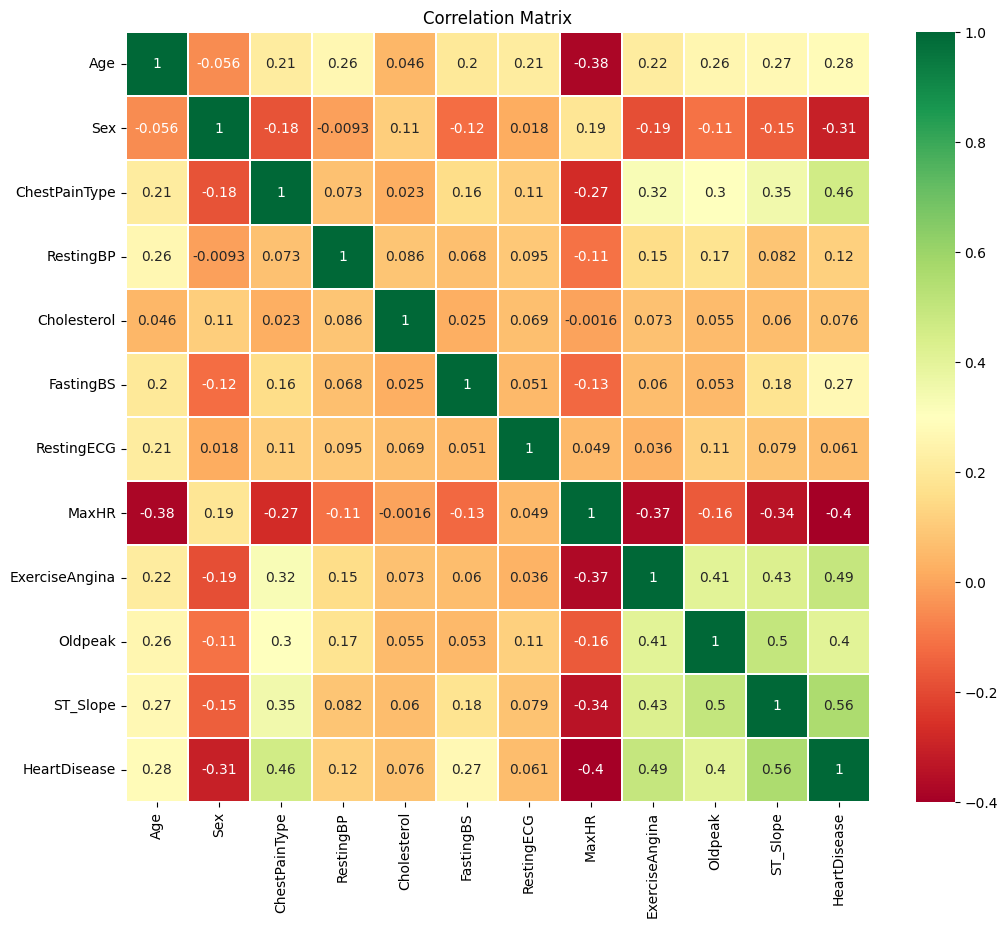

In [200]:
data_encoded = data_clean.copy()
data_encoded['Sex'] = data_encoded['Sex'].map({'M':0, 'F':1})
data_encoded['ChestPainType'] = data_encoded['ChestPainType'].map({'ATA':0, 'NAP':1, 'ASY':2, 'TA':3})
data_encoded['RestingECG'] = data_encoded['RestingECG'].map({'Normal':0, 'ST':1, 'LVH':2})
data_encoded['ExerciseAngina'] = data_encoded['ExerciseAngina'].map({'N':0, 'Y':1})
data_encoded['ST_Slope'] = data_encoded['ST_Slope'].map({'Up':0, 'Flat':1, 'Down':2})

corr = data_encoded.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='RdYlGn', linewidths=0.2, annot_kws={'size':10})
plt.title('Correlation Matrix')
plt.show()



As we can see, our previous assumptions were correct:
- MaxHR (necgatively) and sex (being male) are the most strongly correlated with having the disease;
- ST_Slope, Exercise Angina and type of Chest Pain are also influental to the disease.
- It might be important to notice, that although age is not strongly correlated with the disease itself, it is correlated with max heart rate, which is itself connected to HD.


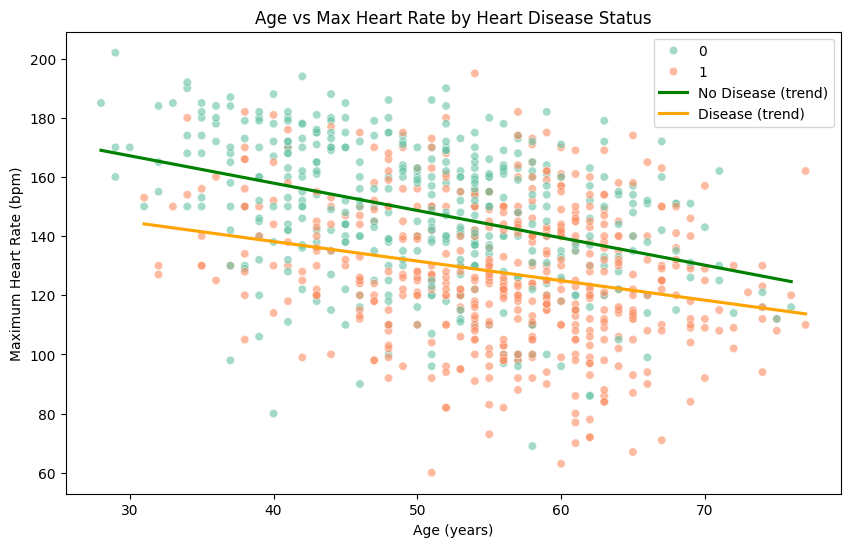

In [201]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Age', y='MaxHR', hue='HeartDisease', data=data_clean, alpha=0.6, palette='Set2')
sns.regplot(x='Age', y='MaxHR', data=data_clean[data_clean['HeartDisease']==0], 
            scatter=False, label='No Disease (trend)', color='green', ci=None)
sns.regplot(x='Age', y='MaxHR', data=data_clean[data_clean['HeartDisease']==1], 
            scatter=False, label='Disease (trend)', color='orange', ci=None)
plt.title('Age vs Max Heart Rate by Heart Disease Status')
plt.xlabel('Age (years)')
plt.ylabel('Maximum Heart Rate (bpm)')
plt.legend()
plt.show()


As we can see, a good part of affected individuals have lower maximum heart rate, and the opposite can be said about healthy individuals.  

# Conclusion


This data analysis of the heart disease was conducted on dataset with 918 subjects and 12 features

### Data quality
- The dataset contained no missing values, but 172 zero entries in Cholesterol and 1 zero in RestingBP, which is unrealistic for an alive adult. They were filled-in with medians for their columns.
- IQR analysys showed ~5% outliers in Cholesterol and ~3% in RestingBP. Given their potential clinical relevance, they were not removed.
- The target variable (Heart Disease) is reasonably balanced: 55.3% of patients have heart disease, 44.7% don't.

### Strongest Predictors
Based on univariate, bivariate and correlation analysis, the following features show the strongest associations with heart disease:

- ExerciseAngina (Yes) -- 85% disease rate (vs 35% for No)
- ST_Slope (Flat or Down) -- 80% disease rate (vs 20% for Up) 
- ChestPainType (ASY) -- 79% disease rate (vs 14% for ATA) 
- FastingBS (1) -- 79% disease rate (vs 48% for 0) 
- Sex (Male) -- 63% disease rate (vs 26% for Female) 
- MaxHR -- strong negative correlation (r = -0.40), lower max heart rate linked to disease 
- Oldpeak -- ntrong positive correlation (r = 0.40), higher ST depression linked to disease 
- Age -- moderate positive correlation (r = 0.28), older age increases risk 

- The scatter plot of 'Age' vs 'MaxHR' colored by 'HeartDisease' showed that at any given age, diseased individuals tend to have lower maximum heart rates, than healthy ones. 

## Feature engeneering
* The dataset has 0 values where there shan't be any (resting BP, cholesterol), which should be taken into account.
### For human research
* The Oldpeak feature is vague. Perhaps, assigning groups to values (e.g. 'small', 'medium', 'high') would make analysis more clear.
* As of now, some features in the dataset are ordial, like age and heart rate, but could benifit from beaing categorial instead. This would allow to see non-linear dependencies between features.
* Fasting BP is made categorial -- if it's above 120, then it's assigned the value of 1. Same could be done for cholesterol & resting bp, based on some clinical "normal" thresholds.
### For machine learning
* If we intend to train a model, then somewhat opposite advice can be given: apply one-hot encoding for categorial features, so they are not left out.
* Perhaps create interaction features, like: 'Age * MaxHR' or 'ChestPainType * ST_Slope'. They can reveal new dependencies.
